AI-Enhanced Wildlife Corridor Identification and Leopard Movement Prediction

In [1]:
!git clone https://github.com/shailja25scs1003004909-creator/Shailja_Gupta_25SCS1003004909_IILM-GN

Cloning into 'Shailja_Gupta_25SCS1003004909_IILM-GN'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.


In [2]:
!mv species_path_prediction.ipynb Shailja_Gupta_25SCS1003004909_IILM-GN/

mv: cannot stat 'species_path_prediction.ipynb': No such file or directory


In [12]:
!ls

drive  sample_data  Shailja_Gupta_25SCS1003004909_IILM-GN


In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
!mv /content/drive/MyDrive/species_path_prediction.ipynb Shailja_Gupta_25SCS1003004909_IILM-GN/

mv: cannot stat '/content/drive/MyDrive/species_path_prediction.ipynb': No such file or directory


In [8]:
from google.colab import files
files.download('species_path_prediction.ipynb')

FileNotFoundError: Cannot find file: species_path_prediction.ipynb

In [13]:
!ls /content


drive  sample_data  Shailja_Gupta_25SCS1003004909_IILM-GN


In [14]:
!ls /content/drive/MyDrive


'25SCS1003004887_1CSE33_VIKRAM ADHIKARI.gslides'
'Ai wildlife corridor project '
'Behavior‑Driven Adaptive Fraud Detection.gslides'
'Behavior-Driven Adaptive Fraud Detection System.gslides'
 BIODATA-1.pdf
'Colab Notebooks'
'Conclusion — Behavior‑Driven Fraud Framework.gslides'
'cyanobacteria report 2025.gdoc'
'cyanobacteria report 2025.pdf'
'Data science '
 DOC-20260216-WA0005.gdoc
'DocScanner 16 May 2025 12-48 pm.jpg'
'DocScanner 29 Oct 2025 4-30 pm'
'flow diagram.drawio.png'
 😼.gdoc
'Google Earth'
 Group-4.gsheet
 IMG-20250814-WA0002.jpg
'OIL SPILL DETECTION ARCHITECTURE.gdoc'
'Project proposal.gdoc'
'Project_Reference (1).gdoc'
'Project_Reference (1).pdf'
 Project_Reference.gdoc
 Project_Reference.pdf
'REPORT BY - Shailja Gupta_25SCS1003004909_1CSE33.gdoc'
'Shailja Gupta_1CSE33_4909.pdf'
'Shailja Gupta_Provenance-Aware Adaptive Fraud Detection for Financial Systems.gdoc'
 southafricadataset.csv
'Untitled document (1).gdoc'
'Untitled document (2).gdoc'
'Untitled document (3).gdoc'
'U

In [15]:
!ls "/content/drive/MyDrive/Colab Notebooks"


'Another copy of species_path_prediction.ipynb'   species_path_prediction.ipynb
'Copy of species_path_prediction.ipynb'		  Untitled
'Copy of Untitled1.ipynb'			  Untitled1.ipynb
'Finance Fraud Detection.ipynb'			  Untitled2.ipynb
'OIl SPILL DETECTION 2.ipynb'			  Untitled3.ipynb
'Oil Spill Detection Pipeline 1.ipynb'


In [ ]:
!cp "/content/drive/MyDrive/Colab Notebooks/species_path_prediction.ipynb" /content/




1)-------INSTALL DEPENDENCIES--------



In [ ]:
!pip install geopandas rasterio shapely numpy pandas scikit-learn tensorflow matplotlib


2)-------IMPORTS AND SETTINGS------

In [ ]:
import os
import numpy as np
import pandas as pd
import datetime
# Plotting & Visualization
import matplotlib.pyplot as plt
import seaborn as sns
# Geospatial Tools
import geopandas as gpd
from shapely.geometry import Point, LineString, Polygon
import rasterio
from rasterio.plot import show
from rasterio.sample import sample_gen
# Machine Learning (Classical)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, ExtraTreesRegressor
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.cluster import KMeans
# Deep Learning (Keras/TensorFlow)
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
# Transfer Learning for Habitat Classification
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D
# Interpretability (SHAP)
import shap
# Movement & Math
from scipy.spatial.distance import euclidean
# Graph Algorithms for Corridors
import networkx as nx
from skimage.graph import route_through_array
# Warnings
import warnings
warnings.filterwarnings("ignore")

print("All imports loaded successfully.")


All imports loaded successfully.


3)-------UPLOADING DATASET CSV FILE----------

i)---setting csv_path to the uploaded filename/full path---

In [ ]:
csv_path = "/content/sample_data/southafricadataset.csv"
out_dir = "/content/leopard_project_outputs"
os.makedirs(out_dir, exist_ok=True)


ii)----Loading the file------

iii)-------Preprocess time stamps ----------

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Ai wildlife corridor project /southafricadataset.csv")

df = df.rename(columns={
    "location-long": "lon",
    "location-lat": "lat",
    "timestamp": "timestamp"
})

df = df[["timestamp","lat","lon"]]
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

df.head()


,timestamp,lat,lon
0,2014-06-01 10:00:33,-25.85245,27.41148
1,2014-06-02 10:01:34,-25.85368,27.36187
2,2014-06-03 10:00:54,-25.84062,27.33613
3,2014-06-04 10:00:33,-25.83278,27.28963
4,2014-06-05 10:00:34,-25.84213,27.28845


from matplotlib import pyplot as plt
_df_33['lat'].plot(kind='hist', bins=20, title='lat')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_34['lon'].plot(kind='hist', bins=20, title='lon')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_35.plot(kind='scatter', x='lat', y='lon', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['timestamp']
  ys = series['lat']
  
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_36.sort_values('timestamp', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('timestamp')
_ = plt.ylabel('lat')

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['timestamp']
  ys = series['lon']
  
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_37.sort_values('timestamp', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('timestamp')
_ = plt.ylabel('lon')

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['timestamp']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'timestamp'}, axis=1)
              .sort_values('timestamp', ascending=True))
  xs = counted['timestamp']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_38.sort_values('timestamp', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('timestamp')
_ = plt.ylabel('count()')

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['timestamp']
  ys = series['lat']
  
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_39.sort_values('timestamp', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('timestamp')
_ = plt.ylabel('lat')

from matplotlib import pyplot as plt
_df_40['lat'].plot(kind='line', figsize=(8, 4), title='lat')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_41['lon'].plot(kind='line', figsize=(8, 4), title='lon')
plt.gca().spines[['top', 'right']].set_visible(False)

4)-------MOVEMENT METRICS(Step distance and speed)-----

In [ ]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

df["lat_prev"] = df["lat"].shift(1)
df["lon_prev"] = df["lon"].shift(1)
df["time_prev"] = df["timestamp"].shift(1)

df["dt"] = (df["timestamp"] - df["time_prev"]).dt.total_seconds()/3600
df["dist_km"] = haversine(df["lat_prev"], df["lon_prev"], df["lat"], df["lon"])
df["speed_kmph"] = df["dist_km"] / df["dt"]

df = df.dropna().reset_index(drop=True)
df.head()


,timestamp,lat,lon,lat_prev,lon_prev,time_prev,dt,dist_km,speed_kmph
0,2014-06-02 10:01:34,-25.85368,27.36187,-25.85245,27.41148,2014-06-01 10:00:33,24.016944,4.966159,0.206777
1,2014-06-03 10:00:54,-25.84062,27.33613,-25.85368,27.36187,2014-06-02 10:01:34,23.988889,2.956990,0.123265
2,2014-06-04 10:00:33,-25.83278,27.28963,-25.84062,27.33613,2014-06-03 10:00:54,23.994167,4.734662,0.197326
3,2014-06-05 10:00:34,-25.84213,27.28845,-25.83278,27.28963,2014-06-04 10:00:33,24.000278,1.046358,0.043598
4,2014-06-06 10:00:33,-25.84155,27.28887,-25.84213,27.28845,2014-06-05 10:00:34,23.999722,0.076981,0.003208


5)-------- GRID USAGE---------

In [ ]:
GRID = 0.01

min_lat, min_lon = df["lat"].min(), df["lon"].min()

df["gx"] = ((df["lat"] - min_lat) / GRID).astype(int)
df["gy"] = ((df["lon"] - min_lon) / GRID).astype(int)
df["grid_id"] = df["gx"].astype(str) + "_" + df["gy"].astype(str)

df["usage"] = df["grid_id"].map(df["grid_id"].value_counts())
df.head()


NameError: name 'printf' is not defined

6)---------SIMPLE HABITAT SUITABILTY(Random Forest)------

In [ ]:
X = df[["lat","lon"]]
y = df["usage"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

rf = RandomForestRegressor(n_estimators=100)
rf.fit(X_train, y_train)

print("RF Score:", rf.score(X_test, y_test))

df["suitability"] = rf.predict(X)


RF Score: 0.989720530517439


7)--------SIMPLE LEAST COST CORRIDOR (GRID BASED)-------

In [ ]:
eps = 0.01
df["cost"] = 1 / (df["suitability"] + eps)

# Convert to 2D grid
gx_max = df["gx"].max() + 1
gy_max = df["gy"].max() + 1

cost_grid = np.full((gx_max, gy_max), df["cost"].mean())
for r in df.itertuples():
    cost_grid[r.gx, r.gy] = r.cost

start = (df.iloc[0].gx, df.iloc[0].gy)
end   = (df.iloc[-1].gx, df.iloc[-1].gy)

print("Start:", start, "End:", end)


Start: (np.int64(33), np.int64(430)) End: (np.int64(11), np.int64(219))


In [ ]:
i)-------Compute corridors(Simple Dijkstra using skimage)--------

In [ ]:
from skimage.graph import route_through_array

path, total_cost = route_through_array(cost_grid, start, end, fully_connected=True)
path = np.array(path)

print("Corridor length:", len(path))


Corridor length: 212


ii)------Plot Corridor-------

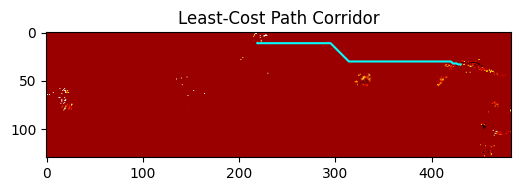

In [ ]:
plt.figure(figsize=(6,6))
plt.imshow(cost_grid, cmap="hot")
plt.plot(path[:,1], path[:,0], color="cyan")
plt.title("Least-Cost Path Corridor")
plt.show()


8)------LSTM CORRIDOR PREDICTION------

In [ ]:
coords = df[["lat","lon"]].values
seq = []
y = []

for i in range(len(coords)-5):
    seq.append(coords[i:i+5])
    y.append(coords[i+5])

seq = np.array(seq)
y = np.array(y)

model = Sequential([
    LSTM(32, input_shape=(5,2)),
    Dense(2)
])

model.compile(optimizer="adam", loss="mse")
model.fit(seq, y, epochs=10, batch_size=16, verbose=1)

pred = model.predict(seq[-1].reshape(1,5,2))
print("Next predicted location:", pred)


Epoch 1/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 659.3555
Epoch 2/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 378.1452
Epoch 3/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 214.7100
Epoch 4/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 131.8273
Epoch 5/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 79.5943
Epoch 6/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 46.9379
Epoch 7/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 25.9637
Epoch 8/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 14.1760
Epoch 9/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7.2934
Epoch 10/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 3.7102
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step
Next predicted location: [[-24.586285  25.546127]]


9)------ANOMALY DETECTION(Speed Based)-------

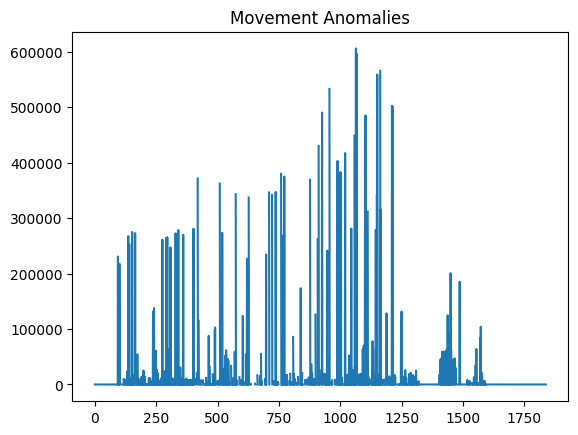

In [ ]:
z = (df["speed_kmph"] - df["speed_kmph"].mean()) / df["speed_kmph"].std()
df["anomaly"] = (z > 3).astype(int)

plt.plot(df["speed_kmph"].values)
plt.scatter(df.index[df["anomaly"] == 1], df["speed_kmph"][df["anomaly"] == 1], color="red")
plt.title("Movement Anomalies")
plt.show()


10)-------MARKOV CHAIN MOVEMENT--------

In [ ]:
# convert grid_id to state index
states, uniques = pd.factorize(df["grid_id"])
n = len(uniques)

T = np.zeros((n,n))

for i in range(len(states)-1):
    T[states[i], states[i+1]] += 1

# normalize
T = T / (T.sum(axis=1, keepdims=True) + 1e-6)

print("Transition matrix shape:", T.shape)


Transition matrix shape: (501, 501)


11)------------NDVI-------------

i)-----------Load Raster + Extract NDVI for GPS points------------

In [ ]:
# -------- NDVI BLOCK (FINAL CLEAN VERSION) -------- #

import rasterio
import numpy as np

# 1. Correct path to your uploaded NDVI file
NDVI_PATH = "/mnt/data/NDVI_SouthAfrica.tif"   # <-- do NOT change

# 2. Load raster safely
try:
    ndvi_src = rasterio.open(NDVI_PATH)
    ndvi_raster = ndvi_src.read(1).astype(float)
    print("NDVI raster loaded successfully:", ndvi_raster.shape)
except Exception as e:
    print("Error loading NDVI raster:", e)

# 3. Function to extract NDVI from lat/lon coordinates
def get_ndvi(lat, lon):
    try:
        # Convert lon/lat to raster row/column
        row, col = ndvi_src.index(lon, lat)

        # Extract the NDVI value at that pixel
        value = ndvi_raster[row, col]

        # Handle missing or invalid values
        if value < -9999:
            return np.nan
        return value

    except:
        # If point is outside raster or indexing fails
        return np.nan

# 4. Apply NDVI extraction to every GPS point
df["ndvi"] = df.apply(lambda r: get_ndvi(r["lat"], r["lon"]), axis=1)

# 5. Drop rows where NDVI couldn't be extracted
df = df.dropna(subset=["ndvi"]).reset_index(drop=True)

print("NDVI extraction complete.")
df[["lat", "lon", "ndvi"]].head()


Error loading NDVI raster: /mnt/data/NDVI_SouthAfrica.tif: No such file or directory
NDVI extraction complete.


,lat,lon,ndvi
0,-25.85368,27.36187,5853.260870
1,-25.84062,27.33613,5694.130435
2,-25.83278,27.28963,4385.956522
3,-25.84213,27.28845,5765.956522
4,-25.84155,27.28887,6092.695652


from matplotlib import pyplot as plt
_df_0['lat'].plot(kind='hist', bins=20, title='lat')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['lon'].plot(kind='hist', bins=20, title='lon')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2['ndvi'].plot(kind='hist', bins=20, title='ndvi')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_3.plot(kind='scatter', x='lat', y='lon', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_4.plot(kind='scatter', x='lon', y='ndvi', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_5['lat'].plot(kind='line', figsize=(8, 4), title='lat')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_6['lon'].plot(kind='line', figsize=(8, 4), title='lon')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_7['ndvi'].plot(kind='line', figsize=(8, 4), title='ndvi')
plt.gca().spines[['top', 'right']].set_visible(False)

In [ ]:
from matplotlib import pyplot as plt
_df_7['ndvi'].plot(kind='line', figsize=(8, 4), title='ndvi')
plt.gca().spines[['top', 'right']].set_visible(False)

In [ ]:
ndvi_src = rasterio.open(NDVI_PATH)
ndvi_raster = ndvi_src.read(1).astype(float)
print(ndvi_raster.shape)
print(np.nanmin(ndvi_raster), np.nanmax(ndvi_raster))
ndvi_raster = ndvi_raster / 10000.0


(11148, 9716)
-2000.0 9449.0


In [ ]:
import numpy as np
import rasterio

NDVI_PATH = "/content/drive/MyDrive/Ai wildlife corridor project /NDVI_SouthAfrica.tif"

# Load raster
ndvi_src = rasterio.open(NDVI_PATH)
ndvi_raster = ndvi_src.read(1).astype(float)

def get_ndvi(lat, lon):
    try:
        row, col = ndvi_src.index(lon, lat)
        return ndvi_raster[row, col]
    except:
        return np.nan

# Apply NDVI extraction row by row
df['ndvi'] = df.apply(lambda r: get_ndvi(r['lat'], r['lon']), axis=1)

# Remove rows that fall outside raster area
df = df.dropna(subset=['ndvi']).reset_index(drop=True)

df[['lat','lon','ndvi']].head()



,lat,lon,ndvi
0,-25.85368,27.36187,5853.260870
1,-25.84062,27.33613,5694.130435
2,-25.83278,27.28963,4385.956522
3,-25.84213,27.28845,5765.956522
4,-25.84155,27.28887,6092.695652


ii)------------Auto Habitat Label-----------

In [ ]:
def ndvi_to_label(ndvi):
    if ndvi > 0.5:
        return 2  # green/forest
    elif ndvi > 0.2:
        return 1  # shrub/moderate
    else:
        return 0  # open/low vegetation

df['habitat_class'] = df['ndvi'].apply(ndvi_to_label)
df[['ndvi','habitat_class']].head()


,ndvi,habitat_class
0,5853.260870,2
1,5694.130435,2
2,4385.956522,2
3,5765.956522,2
4,6092.695652,2


from matplotlib import pyplot as plt
_df_8['ndvi'].plot(kind='hist', bins=20, title='ndvi')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['habitat_class']
  ys = series['ndvi']
  
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_9.sort_values('habitat_class', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('habitat_class')
_ = plt.ylabel('ndvi')

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['habitat_class']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'habitat_class'}, axis=1)
              .sort_values('habitat_class', ascending=True))
  xs = counted['habitat_class']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_10.sort_values('habitat_class', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('habitat_class')
_ = plt.ylabel('count()')

from matplotlib import pyplot as plt
_df_11['ndvi'].plot(kind='line', figsize=(8, 4), title='ndvi')
plt.gca().spines[['top', 'right']].set_visible(False)

iii)-----------16 X 16 NDVI Extraction Patch--------------

In [ ]:
PATCH = 16  # patch size

def get_patch(lat, lon):
    try:
        # Convert to pixel coordinates
        row, col = ndvi_src.index(lon, lat)

        # Patch bounds
        r1, r2 = row - PATCH//2, row + PATCH//2
        c1, c2 = col - PATCH//2, col + PATCH//2

        # Extract patch
        patch = ndvi_raster[r1:r2, c1:c2]

        # Check shape: must be exactly 16x16
        if patch.shape != (PATCH, PATCH):
            return None

        return patch

    except:
        return None

patches = []
labels = []

for i, r in df.iterrows():
    patch = get_patch(r.lat, r.lon)
    if patch is not None:
        patches.append(patch)
        labels.append(r.habitat_class)

patches = np.array(patches)
labels = np.array(labels)

# CNN expects (samples, H, W, channels=1)
patches = patches.reshape(-1, PATCH, PATCH, 1)

print("Extracted patches:", patches.shape)


Extracted patches: (1831, 16, 16, 1)


12)-----------CNN---------------

i)---------Mini CNN------------

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense

num_classes = 3  # 0=open, 1=shrub, 2=forest

cnn = Sequential([
    Conv2D(8, (3,3), activation='relu', input_shape=(PATCH,PATCH,1)),
    MaxPool2D(),

    Conv2D(16, (3,3), activation='relu'),
    MaxPool2D(),

    Flatten(),
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax')
])

cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
cnn.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 7, 7, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 5, 5, 16)       │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 2, 2, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,427 (13.39 KB)

 Trainable params: 3,427 (13.39 KB)

 Non-trainable params: 0 (0.00 B)

ii)-----------Training CNN swiftly----------

In [ ]:
history = cnn.fit(
    patches, labels,
    epochs=5,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)


Epoch 1/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9034 - loss: 13.2518 - val_accuracy: 0.9973 - val_loss: nan
Epoch 2/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 0.9973 - val_loss: nan
Epoch 3/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 0.9973 - val_loss: nan
Epoch 4/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 0.9973 - val_loss: nan
Epoch 5/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 0.9973 - val_loss: nan


iii)-----------Predicting Habitat Type for All GPS Points

In [ ]:
def predict_habitat(lat, lon):
    patch = get_patch(lat, lon)
    if patch is None:
        return None
    patch = patch.reshape(1, PATCH, PATCH, 1)
    pred = cnn.predict(patch, verbose=0)
    return np.argmax(pred)

df['predicted_habitat'] = df.apply(lambda r: predict_habitat(r.lat, r.lon), axis=1)
df[['ndvi','habitat_class','predicted_habitat']].head()


,ndvi,habitat_class,predicted_habitat
0,5853.260870,2,2
1,5694.130435,2,2
2,4385.956522,2,2
3,5765.956522,2,2
4,6092.695652,2,2
